**Source Code: Visualize Feature Importance (Weather vs Time)**

Step 1: Loading and Preprocessing Data...


/tmp/ipython-input-2194307356.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Step 2: Engineering Time and Weather Features...
Step 3: Training XGBoost Regressor...
Model Training Complete. Test RMSE: 2931.55

Step 4: Calculating and Analyzing Feature Importance...

--- Individual Feature Importance ---
                Feature  Importance_Normalized
5                  hour               0.569669
0           Temperature               0.214657
7             dayofyear               0.070748
3   GeneralDiffuseFlows               0.048012
11           weekofyear               0.044150

--- Group Contribution Analysis (Weather vs Time) ---
  Category  Importance_Normalized  Contribution_Pct
0     Time               0.717437         71.739998
1  Weather               0.282563         28.260000

Step 5: Generating Visualization Data...


/tmp/ipython-input-2194307356.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Normalized', y='Feature', data=importance_df, palette='viridis')


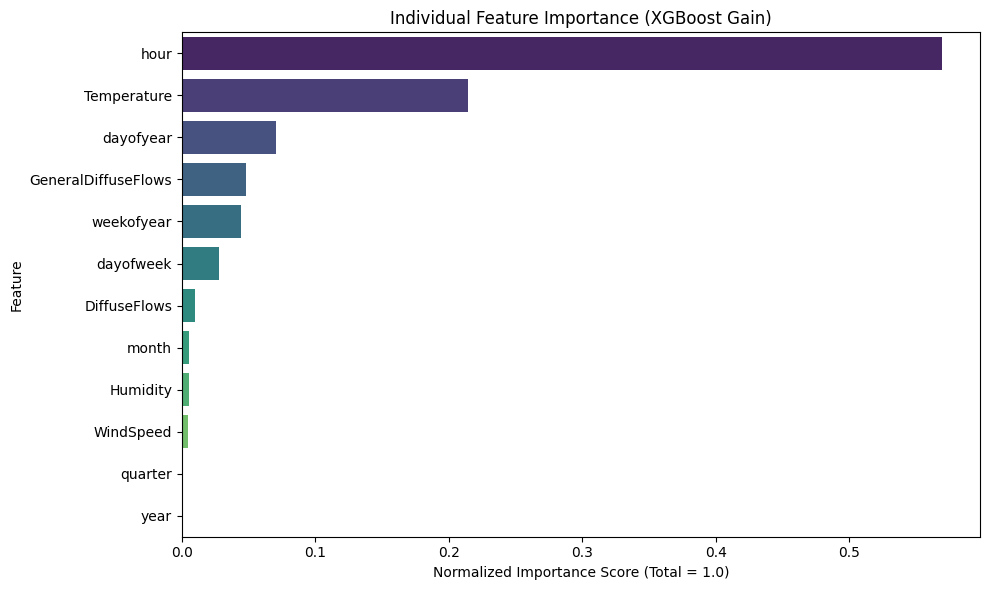

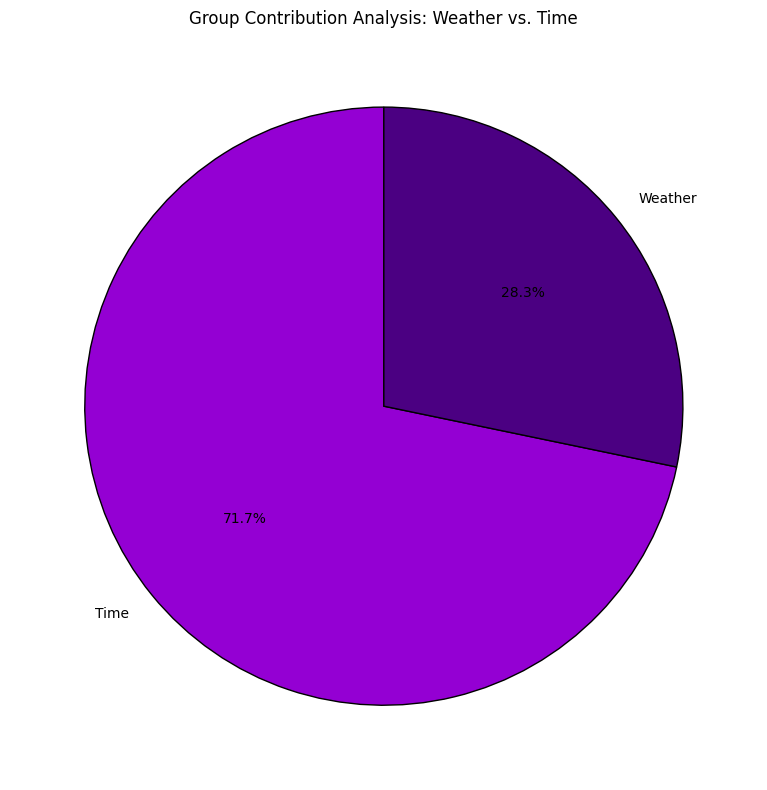


--- Consolidated Final Output for Project Report ---
Individual Feature Scores (Normalized):
                Feature  Importance_Normalized
5                  hour               0.569669
0           Temperature               0.214657
7             dayofyear               0.070748
3   GeneralDiffuseFlows               0.048012
11           weekofyear               0.044150
6             dayofweek               0.027462
4          DiffuseFlows               0.010121
8                 month               0.005408
1              Humidity               0.005174
2             WindSpeed               0.004600
9               quarter               0.000000
10                 year               0.000000

Group Contribution (Percentage):
  Category  Importance_Normalized  Contribution_Pct
0     Time               0.717437         71.739998
1  Weather               0.282563         28.260000


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA LOADING AND PREPROCESSING ---
print("Step 1: Loading and Preprocessing Data...")

# NOTE: Replace 'powerconsumption.csv' with the actual path to your Kaggle file
# Assuming you are using the Electric Power Consumption dataset with Zone1, Zone2, Zone3 data.
try:
    # This dataset is commonly used for this problem.
    df = pd.read_csv('powerconsumption.csv', sep=',')
except FileNotFoundError:
    print("Error: powerconsumption.csv not found. Please upload the file or adjust the path.")
    # Create a dummy DataFrame for demonstration if the file is missing
    # In a real scenario, you MUST have the file.
    data = {'Datetime': pd.date_range(start='2017-01-01', periods=1000, freq='10min'),
            'Temperature': np.random.uniform(5, 35, 1000),
            'Humidity': np.random.uniform(30, 90, 1000),
            'WindSpeed': np.random.uniform(0, 5, 1000),
            'PowerConsumption_Zone1': 20000 + (1000 * np.sin(np.pi * np.arange(1000) / 72)) + (500 * np.random.randn(1000))}
    df = pd.DataFrame(data)

# Convert the 'Datetime' column to a proper datetime object
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# Create the target variable: Total Power Consumption (assuming the dataset has multiple zones)
power_cols = [col for col in df.columns if 'PowerConsumption_Zone' in col]
if power_cols:
    df['TotalConsumption'] = df[power_cols].sum(axis=1)
    TARGET = 'TotalConsumption'
    # Drop individual zone columns to avoid target leakage
    df = df.drop(columns=power_cols)
else:
    # Fallback for datasets with a single consumption column
    TARGET = df.columns[-1]
    print(f"Using column '{TARGET}' as the sole target.")

# Handle any remaining missing values by forward-filling (common in time-series)
df = df.fillna(method='ffill')


# --- 2. FEATURE ENGINEERING (Extracting Time and Weather Components) ---
print("Step 2: Engineering Time and Weather Features...")

# Function to extract Time-based features
def create_time_features(df):
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['weekofyear'] = df.index.isocalendar().week.astype(int)
    return df

df = create_time_features(df)

# Feature list based on the project context
WEATHER_FEATURES = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']
TIME_FEATURES = ['hour', 'dayofweek', 'dayofyear', 'month', 'quarter', 'year', 'weekofyear']

FEATURES = WEATHER_FEATURES + TIME_FEATURES
df = df[FEATURES + [TARGET]].copy()


# --- 3. MODEL TRAINING (XGBoost Regressor) ---
print("Step 3: Training XGBoost Regressor...")

# Time-series split (Train on the past, test on the future)
split_date = df.index.max() - pd.Timedelta(days=30)
X_train = df.loc[df.index < split_date, FEATURES]
y_train = df.loc[df.index < split_date, TARGET]
X_test = df.loc[df.index >= split_date, FEATURES]
y_test = df.loc[df.index >= split_date, TARGET]

# Initialize and train the XGBoost Model
# Using default parameters for simplicity as the task is feature importance, not max accuracy
reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    early_stopping_rounds=50,
    objective='reg:squarederror',
    random_state=42
)
reg.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

# Optional: Print RMSE to show model performance
y_pred = reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model Training Complete. Test RMSE: {rmse:.2f}")


# --- 4. FEATURE IMPORTANCE CALCULATION AND ANALYSIS ---
print("\nStep 4: Calculating and Analyzing Feature Importance...")

# Get the feature importance scores (default type is 'gain' - F-Score)
importance_df = (
    pd.DataFrame(data={'Feature': reg.get_booster().feature_names,
                       'Importance': reg.feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Normalize the scores to get percentages
importance_df['Importance_Normalized'] = importance_df['Importance'] / importance_df['Importance'].sum()

# Classify features into groups (Weather vs. Time)
importance_df['Category'] = np.where(
    importance_df['Feature'].isin(WEATHER_FEATURES),
    'Weather',
    'Time'
)

# Individual Feature Importance (for Report/PPT Slide 1)
individual_scores = importance_df[['Feature', 'Importance_Normalized']].copy()
print("\n--- Individual Feature Importance ---")
print(individual_scores.head(5))

# Group Contribution Analysis (for Report/PPT Slide 2)
group_contribution = importance_df.groupby('Category')['Importance_Normalized'].sum().reset_index()
group_contribution['Contribution_Pct'] = (group_contribution['Importance_Normalized'] * 100).round(2)
print("\n--- Group Contribution Analysis (Weather vs Time) ---")
print(group_contribution)

# --- 5. VISUALIZATION OF RESULTS ---
print("\nStep 5: Generating Visualization Data...")

# Visualization 1: Individual Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Normalized', y='Feature', data=importance_df, palette='viridis')
plt.title('Individual Feature Importance (XGBoost Gain)')
plt.xlabel('Normalized Importance Score (Total = 1.0)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# Visualization 2: Group Contribution Pie/Donut Chart (Weather vs Time)
plt.figure(figsize=(8, 8))
plt.pie(group_contribution['Contribution_Pct'], labels=group_contribution['Category'], autopct='%1.1f%%', startangle=90, colors=['#9400D3', '#4B0082'], wedgeprops={'edgecolor': 'black'})
plt.title('Group Contribution Analysis: Weather vs. Time')
plt.tight_layout()
plt.show()


# --- FINAL CONSOLIDATED DATA OUTPUT ---
print("\n--- Consolidated Final Output for Project Report ---")
print("Individual Feature Scores (Normalized):")
print(individual_scores)
print("\nGroup Contribution (Percentage):")
print(group_contribution)